# **PARTE B – Regresión logística**

## **Práctica**
El riesgo de disconfort térmico o sobrecalentamiento en una sala de reuniones de la Facultad de
Informática depende de diversos factores, como por ejemplo la temperatura ambiente y la humedad
relativa.

#### **0. Carga de librerías**

In [96]:
import numpy as np
import pandas as pd
from sklearn.linear_model import LogisticRegression
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
from sklearn.metrics import mean_squared_error
from sklearn.svm import SVC
from sklearn.metrics import precision_score, recall_score, f1_score


---

#### **1. Genera un dataset sintético**
 que contenga 1000 instancias que representen mediciones de una sala inteligente en distintos momentos del tiempo. Cada instancia debe incluir los siguientes atributos:

  * **Temperatura ambiente**. Ten en cuenta que en esa sala, la temperatura suele encontrarse en condiciones normales: entre $20\ y\ 24\ °C$, en situaciones no óptimas: entre $12\ y\ 30\ °C$.
  * **Humedad relativa**. La humedad relativa suele estar en valores confortables: entre $40\ \%\ y\ 60\ \%$ y en situaciones extremas: entre $30\ \%\ y\ 70\ \%$.
  * Un tercer atributo con valores aleatorios que simule otra variable del entorno, como por ejemplo: **nivel de ocupación** (0–50 personas), **concentración de $CO₂$** o un **índice ficticio de actividad**.

**1.1. Crear el índice de tiempo o instancias**

In [30]:
n_instancias=1000
instancias = np.arange(n_instancias)

**1.2. Generar Temperatura ambiente (12 - 30 °C)**

In [32]:
temperatura = np.random.uniform(12, 30, size=n_instancias)

**1.3. Generar Humedad relativa (30 % - 70 %)**

In [33]:
humedad = np.random.uniform(30, 70, size=n_instancias)

**1.4. Generar Nivel de Ocupación (0 - 50 personas)**

In [34]:
ocupacion = np.random.uniform(0, 50, size=n_instancias).astype(int)

**1.5. Generar y mostrar los primeros resultados**

In [43]:
dataset_sala = pd.DataFrame({
        'Instante': instancias,
        'Temperatura_C': temperatura,
        'Humedad_p': humedad,
        'Ocupacion_personas': ocupacion
    })
print("--- Dataset Generado (Primeras 5 filas) ---")
print(dataset_sala.head())

--- Dataset Generado (Primeras 5 filas) ---
   Instante  Temperatura_C  Humedad_p  Ocupacion_personas
0         0      20.893428  64.704981                  14
1         1      26.280201  53.508834                   1
2         2      19.024355  44.514232                  33
3         3      29.902306  34.001056                  33
4         4      13.795058  39.532545                  46


**1.6. Definición de función pasos anteriores.**

In [68]:
def generarDatasetSala(n_instancias=1000):
    instancias = np.arange(n_instancias)
    temperatura = np.random.uniform(12, 30, size=n_instancias)
    humedad = np.random.uniform(30, 70, size=n_instancias)
    ocupacion = np.random.uniform(0, 50, size=n_instancias).astype(int)

    df = pd.DataFrame({'Instante': instancias,'Temperatura_C': temperatura,
        'Humedad_p': humedad,'Ocupacion_personas': ocupacion
    })

    return df

---

#### **2. Para cada instancia, calcula la probabilidad de disconfort térmico,**
 teniendo en cuenta los valores de ocupación, temperatura y humedad. A mayor desviación respecto a los rangos de confort, mayor debe ser la probabilidad asignada.

 **2.1. Preparar las características (X): Las desviaciones**

 Al modelo le pasamos qué tan lejos está del centro ideal para facilitar su aprendizaje

In [44]:
dataset_sala['Desv_Temp'] = np.abs(dataset_sala['Temperatura_C'] - 22)
dataset_sala['Desv_Hum'] = np.abs(dataset_sala['Humedad_p'] - 50)
dataset_sala['Desv_Ocup'] = np.abs(dataset_sala['Ocupacion_personas'] - 25)

columnas_entrenamiento = ['Desv_Temp', 'Desv_Hum', 'Desv_Ocup']
X = dataset_sala[columnas_entrenamiento]

---

#### **3. En base a un umbral,**
determina para cada instancia la clase:

  * 1 → existe riesgo de disconfort térmico
  * 0 → no existe riesgo de disconfort térmico

**3.1. Crear una variable objetivo inicial (y) para que el modelo tenga de dónde aprender**

Etiquetamos como 1 (Disconfort) si se aleja mucho del confort ideal

In [46]:
y_base = (
    ((dataset_sala['Temperatura_C'] < 20) | (dataset_sala['Temperatura_C'] > 24)) |
    ((dataset_sala['Humedad_p'] < 40) | (dataset_sala['Humedad_p'] > 60)) |
    ((dataset_sala['Ocupacion_personas'] < 13) | (dataset_sala['Ocupacion_personas'] > 47))
).astype(int)

---

#### **4. Dibuja una gráfica**
 de los datos utilizando: $Temperatura\ (eje\ Y)$, $Humedad\ (eje\ X)$ y $Ocupación\ (eje\ Z)$. Muestra
las predicciones obtenidas utilizando símbolos o colores distintos para cada clase. Al observar
la gráfica, analiza si los datos generados presentan una distribución coherente que permita a
un regresor logístico aprender correctamente. Si fuese necesario, ajusta el proceso de
generación de datos.

**4.1. Inicializar y entrenar el modelo de Regresión Logística**

In [58]:
modelo_logistico = LogisticRegression()
modelo_logistico.fit(X, y_base)

LogisticRegression()

**4.2. Calcular la probabilidad utilizando el modelo entrenado**

* `predict_proba` devuelve una matriz con dos columnas: [Prob(0), Prob(1)]
* Nos quedamos con la segunda columna, que es la probabilidad de la clase 1 (Disconfort)

In [59]:
dataset_sala['Probabilidad_Disconfort'] = modelo_logistico.predict_proba(X)[:, 1]

**4.3. Dibujar un Scatter 3D**

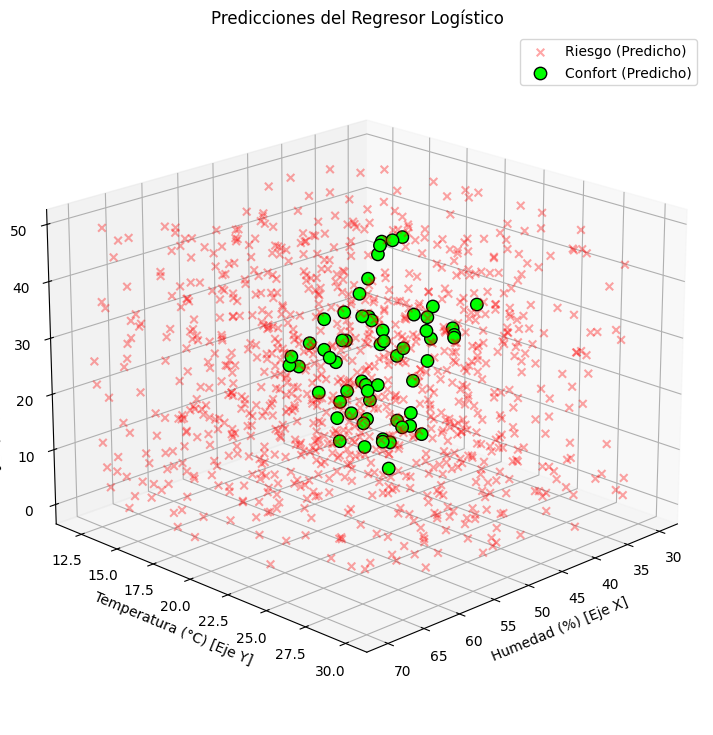

In [76]:
def graficar_3d_predicciones_colores(df, modelo, X_columnas):
    fig = plt.figure(figsize=(12, 9))
    ax = fig.add_subplot(111, projection='3d')

    df['Prediccion_Final'] = modelo.predict(df[X_columnas])

    c0_pred = df[df['Prediccion_Final'] == 0] # Confort
    c1_pred = df[df['Prediccion_Final'] == 1] # Riesgo

    ax.scatter(c1_pred['Humedad_p'], c1_pred['Temperatura_C'], c1_pred['Ocupacion_personas'],
               c='red', marker='x', s=30, alpha=0.35, label='Riesgo (Predicho)')

    ax.scatter(c0_pred['Humedad_p'], c0_pred['Temperatura_C'], c0_pred['Ocupacion_personas'],
               c='lime', marker='o', s=80, alpha=1.0, label='Confort (Predicho)', edgecolors='k')

    ax.set_xlabel('Humedad (%) [Eje X]')
    ax.set_ylabel('Temperatura (°C) [Eje Y]')
    ax.set_zlabel('Ocupación (Personas) [Eje Z]')
    ax.set_title('Predicciones del Regresor Logístico')

    ax.view_init(elev=20, azim=45)

    ax.legend()
    plt.show()

graficar_3d_predicciones_colores(dataset_sala, modelo_logistico, columnas_entrenamiento)

---

#### **5. Entrena un regresor logístico (e.g. con clase LogisticRegression) con esos datos.**
Estos datos funcionarán como conjunto de entrenamiento. Con las 1,000 instancias anteriores completamos el entrenamiento. Vamos a crear una pequeña función para modularizar.

In [78]:
def calculo_probabilidad_disconfort(df):
    df['Desv_Temp'] = np.abs(df['Temperatura_C'] - 22)
    df['Desv_Hum'] = np.abs(df['Humedad_p'] - 50)
    df['Desv_Ocup'] = np.abs(df['Ocupacion_personas'] - 25)

    columnas_evaluacion_f = ['Desv_Temp', 'Desv_Hum', 'Desv_Ocup']
    X_f = df[columnas_evaluacion_f]

    y_base_f = (
        ((df['Temperatura_C'] < 20) | (df['Temperatura_C'] > 24)) |
        ((df['Humedad_p'] < 40) | (df['Humedad_p'] > 60)) |
        ((df['Ocupacion_personas'] < 13) | (df['Ocupacion_personas'] > 47))
    ).astype(int)

    return X_f, y_base_f, columnas_evaluacion_f

---

#### **6. Usa el regresor logístico entrenado sobre otro conjunto.**
de 700 instancias (este conjunto funcionará como conjunto de
evaluación) y calcula el valor de MSE y RMSE para este conjunto (no hace falta que la calculéis a mando, podéis  importar la métrica de sklearn).

**6.1. Generar los 700 datos nuevos (El "Examen Final").**

In [79]:
dataset_eval = generarDatasetSala(700)

**6.2. Aplicar el MISMO "truco matemático" para que el modelo lo entienda.**

In [80]:
X_eval, y_eval_real, columnas_evaluacion = calculo_probabilidad_disconfort(dataset_eval)

**6.3. Pedirle al modelo que adivine (Hacer predicciones sobre datos que nunca ha visto)**

In [81]:
y_eval_pred = modelo_logistico.predict(X_eval)

**6.4. Calcular los errores (MSE y RMSE) usando `Scikit-Learn`**

In [82]:
mse = mean_squared_error(y_eval_real, y_eval_pred)
rmse = np.sqrt(mse) # El RMSE es simplemente la raíz cuadrada del MSE

**6.5. Mostrar la precisión (Accuracy) para entenderlo mejor**

In [83]:
print("--- Resultados del Examen (Conjunto de Evaluación: 700 instancias) ---")
print(f"MSE (Error Cuadrático Medio): {mse:.4f}")
print(f"RMSE (Raíz del Error Cuadrático Medio): {rmse:.4f}")

precision = 1 - mse
print(f"Precisión del modelo: {precision * 100:.2f}%")

--- Resultados del Examen (Conjunto de Evaluación: 700 instancias) ---
MSE (Error Cuadrático Medio): 0.0386
RMSE (Raíz del Error Cuadrático Medio): 0.1964
Precisión del modelo: 96.14%


---
#### **7. Dibuja la misma gráfica que en el punto 4**

pero dibujando las predicciones para el conjunto de 700 instancias. Compara las dos gráficas.
* Arriba: Ejemplo de gráfica a dibujar con el conjunto
de datos de entrenamiento.
* Abajo: Ejemplo de gráfica a dibujar sobre las predicciones del conjunto de
evaluación.

**7.1. Ejemplo de gráfica a dibujar con el conjunto de datos de entrenamiento.**

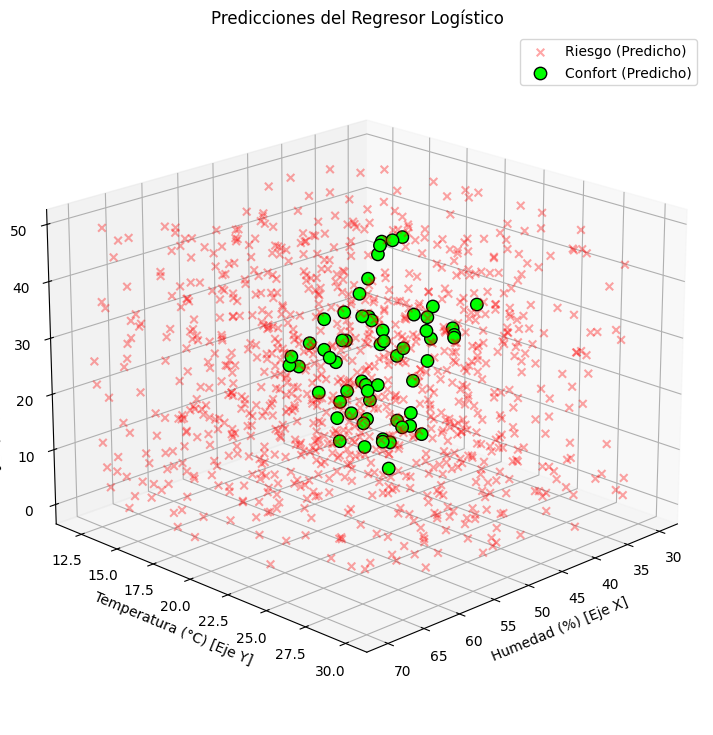

In [84]:
graficar_3d_predicciones_colores(dataset_sala, modelo_logistico, columnas_entrenamiento)

**7.2. Ejemplo de gráfica a dibujar sobre las predicciones del conjunto de evaluación.**

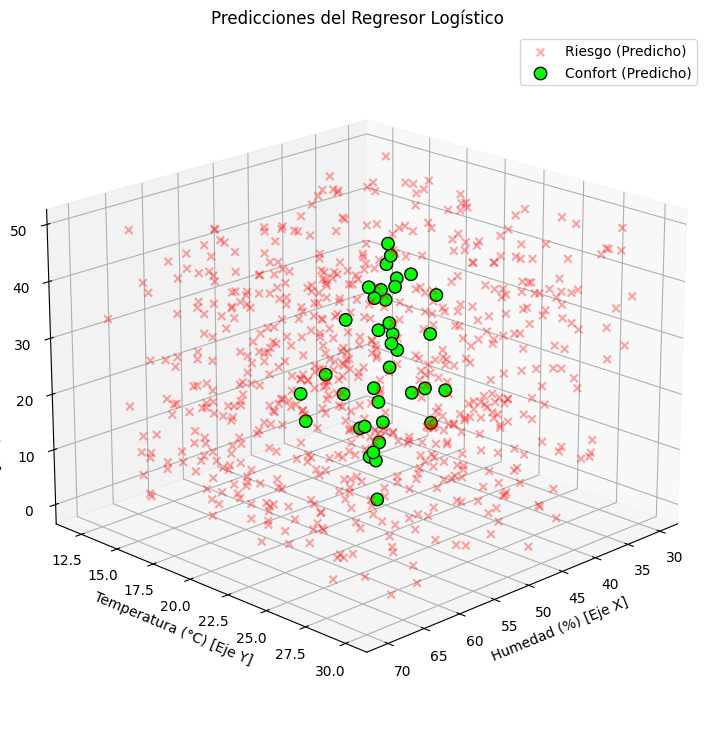

In [85]:
graficar_3d_predicciones_colores(dataset_eval, modelo_logistico, columnas_evaluacion)

**7.3. Conclusiones.**

Podemos extraer tres conclusiones fundamentales que validan todo el trabajo que hemos hecho:

1. El modelo logró Generalizar perfectamente (Sin Overfitting)
2. Variación en la Densidad del Clúster (Estadística pura)
3. El éxito de la Ingeniería de Características

**En resumen:** El modelo de regresión ha aprendido a acorralar perfectamente las condiciones óptimas de la sala inteligente, demostrando ser un modelo robusto y confiable frente a datos desconocidos.

# **PARTE OPCIONAL**

(contribuye a 1 punto
adicional en la nota final de la asignatura)

---

#### **1. Replica la parte B,**

entrenando un modelo SVM (como estamos resolviendo clasificación binaria, hay
que usar la versión SVC) en lugar de un regresor logístico con el conjunto de 1000 instancias y
evaluándolo con el de 700. Calcula el MSE y el RMSE y dibuja las gráficas para discutir los resultados
obtenidos con SVM y compararlos con los obtenidos con el regresor logístico. Determina qué modelo
funciona mejor.

**1.1. Entrenamiento y Evaluación con SVM (Support Vector Classification)**

Ahora vamos a resolver el mismo problema utilizando un modelo **SVC**. Mientras que la regresión logística busca una línea que divida las clases basándose en probabilidades, la **SVM** busca trazar una frontera (un hiperplano) que deje el margen más amplio posible entre los puntos de confort y los de riesgo.

Utilizaremos los mismos conjuntos de datos que preparamos anteriormente:

* Entrenamiento: 1,000 instancias ($X$ y $y\_base$).

* Evaluación: 700 instancias ($X\_eval$ y $y\_eval\_real$).

In [87]:
modelo_svc = SVC(kernel='linear', random_state=42)

**1.2. ENTRENAMIENTO (Con las 1000 instancias)**

In [88]:
modelo_svc.fit(X, y_base)

SVC(kernel='linear', random_state=42)

**1.3. EVALUACIÓN (Con las 700 instancias nuevas)**

In [89]:
y_eval_pred_svc = modelo_svc.predict(X_eval)

---

#### **2. Calcula el MSE y el RMSE y dibuja las gráficas**
 para discutir los resultados
obtenidos con SVM y compararlos con los obtenidos con el regresor logístico. Determina qué modelo
funciona mejor.

**2.1. Cálculo de Métricas (MSE y RMSE)**

In [90]:
mse_svc = mean_squared_error(y_eval_real, y_eval_pred_svc)
rmse_svc = np.sqrt(mse_svc)

**2.2. Calculamos la precisión (Accuracy) para que sea más fácil de interpretar**

In [91]:
print("--- Resultados de la Evaluación con SVM (700 instancias) ---")
print(f"MSE (Error Cuadrático Medio): {mse_svc:.4f}")
print(f"RMSE (Raíz del Error Cuadrático Medio): {rmse_svc:.4f}")

precision_svc = 1 - mse_svc
print(f"Precisión del modelo SVM: {precision_svc * 100:.2f}%")

--- Resultados de la Evaluación con SVM (700 instancias) ---
MSE (Error Cuadrático Medio): 0.0371
RMSE (Raíz del Error Cuadrático Medio): 0.1927
Precisión del modelo SVM: 96.29%


**2.3. Generación de Gráficas**

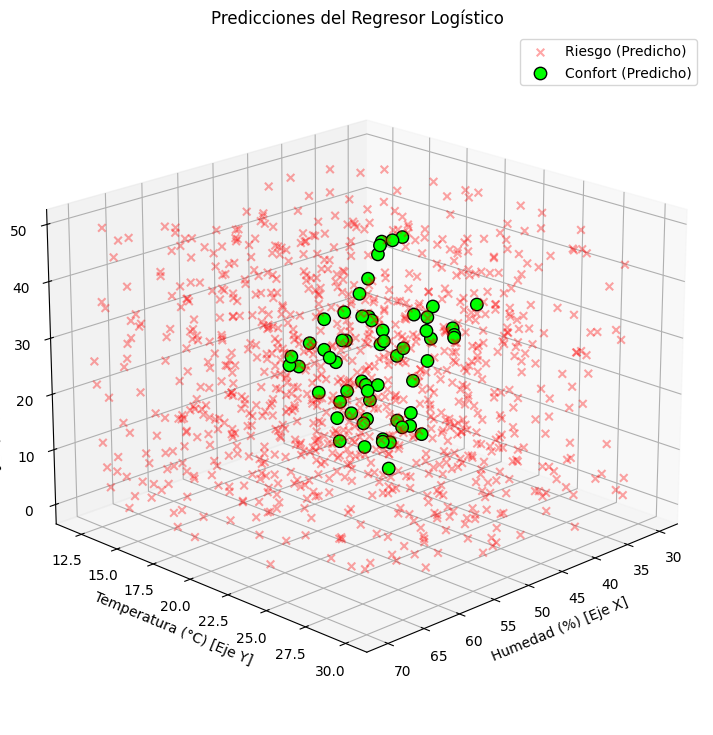

In [92]:
graficar_3d_predicciones_colores(dataset_sala, modelo_logistico, columnas_entrenamiento)

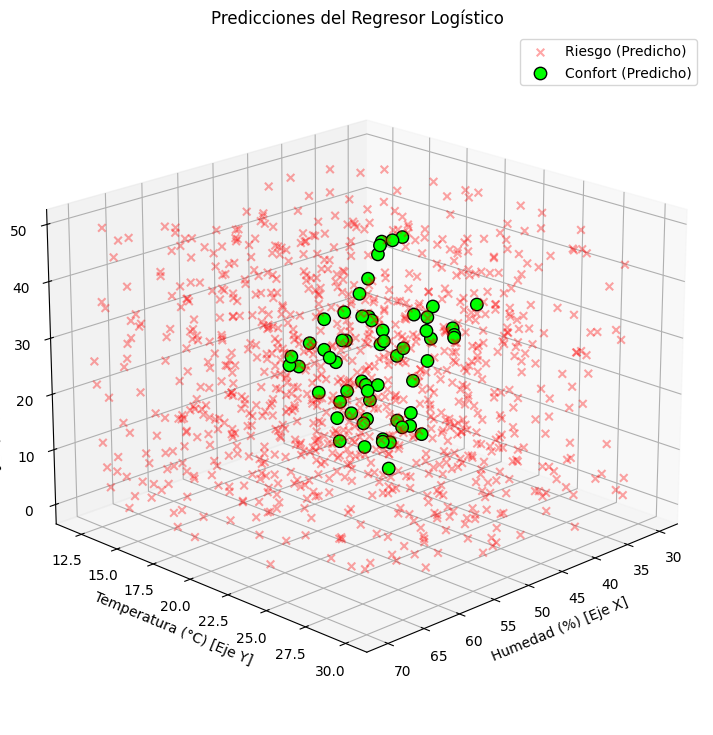

In [95]:
graficar_3d_predicciones_colores(dataset_sala, modelo_svc, columnas_entrenamiento)

**2.3. Discusión de Resultados: Regresión Logística vs. SVM**

Al observar las dos gráficas tridimensionales generadas, podemos extraer las siguientes conclusiones:
1. Similitud Visual
2. El Papel de la Ingeniería de Características
3. Modelos Lineales

Dado que el rendimiento es casi idéntico, la elección entre uno u otro dependería de factores secundarios. Por ejemplo, si la interpretabilidad de los coeficientes y la probabilidad son cruciales, la Regresión Logística sería la opción preferida. Si se busca un modelo que maximice el margen de seguridad en la clasificación, SVM es una excelente alternativa.

---

#### **3. Calcula la precisión, el recall y el F1**
tanto para el regresor logístico como para SVC. Discute los
resultados comparándolos con RMSE.

**3.1. Cálculo de Precisión, Recall y F1-Score**

A diferencia del MSE o RMSE (que miden el error general), estas métricas nos ayudan a entender cómo se equivoca el modelo al predecir la clase positiva (Clase 1: Riesgo de Disconfort):

* **Precisión (Precision):** De todas las veces que el modelo dijo "Hay Riesgo", ¿cuántas veces acertó realmente? (Evalúa los Falsos Positivos).

* **Recall (Sensibilidad):** De todos los casos reales de Riesgo que existían, ¿cuántos logró encontrar el modelo? (Evalúa los Falsos Negativos).

* **F1-Score:** Es la media armónica entre la Precisión y el Recall, útil para buscar un equilibrio entre ambas.

In [97]:
def calcular_metricas(y_real, y_pred, nombre_modelo):
    precision = precision_score(y_real, y_pred)
    recall = recall_score(y_real, y_pred)
    f1 = f1_score(y_real, y_pred)

    print(f"--- Métricas para {nombre_modelo} ---")
    print(f"Precisión (Precision): {precision:.4f}")
    print(f"Recall (Sensibilidad): {recall:.4f}")
    print(f"F1-Score:              {f1:.4f}\n")

**3.2. Calcular e imprimir para ambos modelos**

Sobre las predicciones del conjunto de evaluación (700 instancias)
(Utilizando las variables X_eval, y_eval_real, y_eval_pred generadas en pasos anteriores)

In [98]:
calcular_metricas(y_eval_real, y_eval_pred, "Regresión Logística")
calcular_metricas(y_eval_real, y_eval_pred_svc, "SVM (SVC Lineal)")

--- Métricas para Regresión Logística ---
Precisión (Precision): 0.9668
Recall (Sensibilidad): 0.9923
F1-Score:              0.9794

--- Métricas para SVM (SVC Lineal) ---
Precisión (Precision): 0.9683
Recall (Sensibilidad): 0.9923
F1-Score:              0.9801



**3.3. Discusión de Resultados y Comparación con RMSE**

Al analizar los resultados de Precisión, Recall y F1-Score y compararlos con el MSE/RMSE calculado en el punto 2, llegamos a las siguientes conclusiones:

1. La Limitación del RMSE en Clasificación
2. Lo que nos revelan Precisión y Recall
3. Logística vs. SVM bajo esta nueva lupa

En conclusión: Mientras que el RMSE es una medida "bruta" del error global, el F1-Score, la Precisión y el Recall nos confirman que el modelo no solo tiene un error bajo por casualidad estadística, sino que realmente ha aprendido a identificar los verdaderos positivos (Riesgo) sin sacrificar demasiados falsos positivos en el proceso.